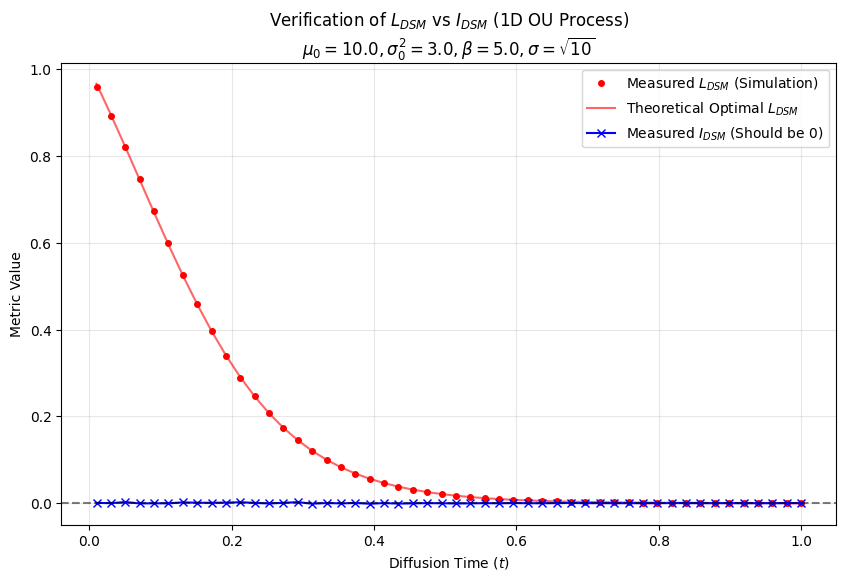

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定 (與手算一致)
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
sigma_q = np.sqrt(10.0)  # 雜訊強度 sigma
n_samples = 100000       # 使用大量樣本來減少隨機誤差

# 時間點設定 (從接近 0 到 T =1.0)
t_steps = np.linspace(0.01, 1.0, 50)
ldsm_history = []
idsm_history = []
theoretical_ldsm = []

for t in t_steps:
    # --- 擴散過程係數 ---
    a_t = np.exp(-beta * t)  #<< mu_t
    # s_t 為雜訊的標準差係數
    s_t = np.sqrt((sigma_q**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t)))
    
    # --- 採樣 ---
    x0 = np.random.normal(mu_0, np.sqrt(var_0), n_samples)
    eps = np.random.normal(0, 1, n_samples)
    xt = a_t * x0 + s_t * eps
    
    # --- 理論最優預測 (Exact Solution) ---
    # 根據我們手算的公式: eps_star = Cov(eps, xt)/Var(xt) * (xt - E[xt])
    var_xt = var_0 * (a_t**2) + s_t**2
    cov_eps_xt = s_t
    mean_xt = mu_0 * a_t
    
    eps_theta = (cov_eps_xt / var_xt) * (xt - mean_xt)
    
    # --- Indicators ---
    # L_DSM = E[(eps_theta - eps)^2]
    l_dsm = np.mean((eps_theta - eps)**2)
    # I_DSM = E[eps_theta * (eps_theta - eps)]
    i_dsm = np.mean(eps_theta * (eps_theta - eps))
    
    # --- 理論預期值 (用來對照) ---
    # 理論 L_DSM = 1 - (s_t^2 / var_xt)
    l_theory = 1 - (s_t**2 / var_xt)
    
    ldsm_history.append(l_dsm)
    idsm_history.append(i_dsm)
    theoretical_ldsm.append(l_theory)

# 2. 繪圖證明
plt.figure(figsize=(10, 6))
plt.plot(t_steps, ldsm_history, 'ro', label='Measured $L_{DSM}$ (Simulation)', markersize=4)
plt.plot(t_steps, theoretical_ldsm, 'r-', label='Theoretical Optimal $L_{DSM}$', alpha=0.6)
plt.plot(t_steps, idsm_history, 'b-x', label='Measured $I_{DSM}$ (Should be 0)')

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(f'Verification of $L_{{DSM}}$ vs $I_{{DSM}}$ (1D OU Process)\n'
          f'$\mu_0={mu_0}, \sigma^2_0={var_0}, \\beta={beta}, \sigma=\sqrt{{10}}$')
plt.xlabel('Diffusion Time ($t$)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


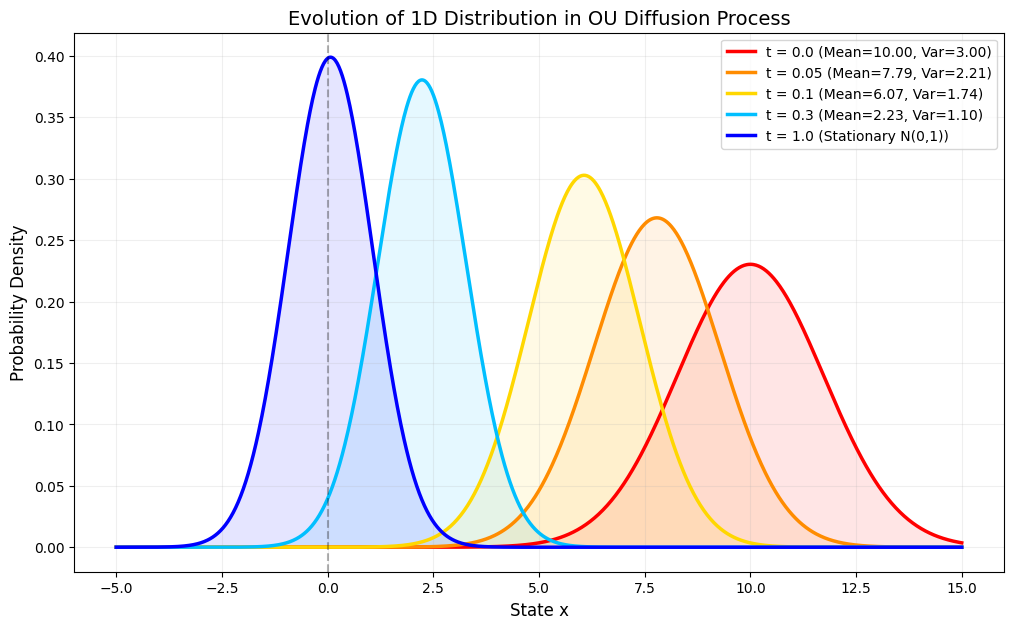

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 參數設定
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
sigma_q = np.sqrt(10.0)

# 選取 5 個時間階段
t_points = [0.0, 0.05, 0.1, 0.3, 1.0]
colors = ['#FF0000', '#FF8C00', '#FFD700', '#00BFFF', '#0000FF'] # 紅到藍

x_axis = np.linspace(-5, 15, 1000)
plt.figure(figsize=(12, 7))

for t, color in zip(t_points, colors):
    # OU 過程解析解的均值與變異數
    a_t = np.exp(-beta * t)
    s_t_sq = (sigma_q**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    
    current_mu = mu_0 * a_t
    current_var = var_0 * (a_t**2) + s_t_sq
    current_std = np.sqrt(current_var)
    
    # 畫出 PDF
    y = norm.pdf(x_axis, current_mu, current_std)
    label = f't = {t} (Mean={current_mu:.2f}, Var={current_var:.2f})'
    if t == 1.0: label = f't = {t} (Stationary N(0,1))'
    
    plt.plot(x_axis, y, label=label, color=color, lw=2.5)
    plt.fill_between(x_axis, y, alpha=0.1, color=color)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.title('Evolution of 1D Distribution in OU Diffusion Process', fontsize=14)
plt.xlabel('State x', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Time (t)   | Mean_xt    | Var_xt     | L_DSM (Opt)  | I_DSM (Opt) 
-----------------------------------------------------------------
0.00       | 10.00      | 3.00       | 1.000214     | 0.000000    
0.05       | 7.79       | 2.21       | 0.822740     | 0.001071    
0.10       | 6.07       | 1.74       | 0.635085     | -0.000624   
0.30       | 2.23       | 1.10       | 0.136095     | -0.000388   
1.00       | 0.07       | 1.00       | 0.000136     | 0.000004    


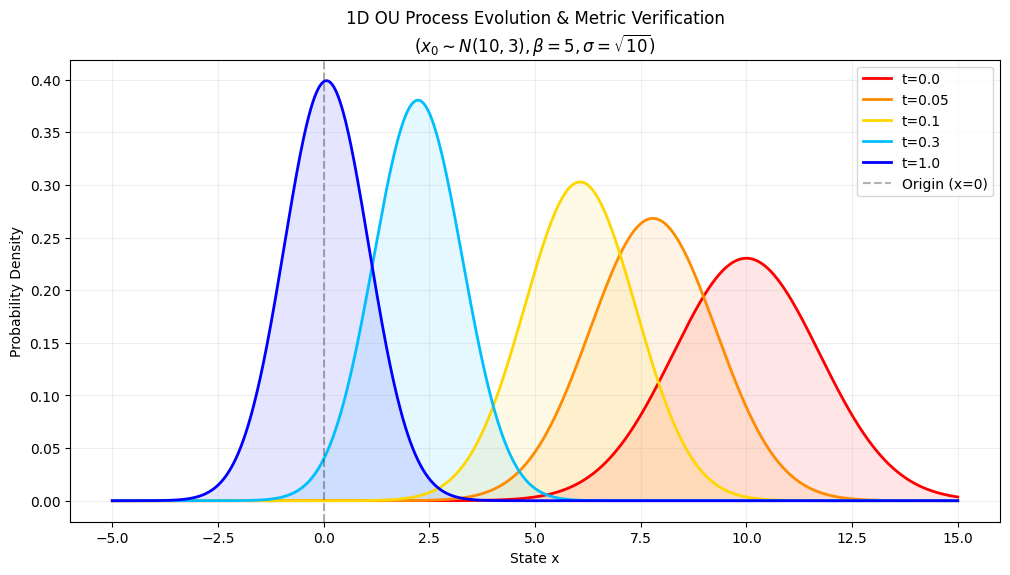

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 參數設定 (與你的推導一致)
mu_0 = 10.0
var_0 = 3.0
beta = 5.0
sigma_q = np.sqrt(10.0)
n_samples = 500000  # 使用大量樣本以確保類比精確度

# 選取 5 個展示階段
t_points = [0.0, 0.05, 0.1, 0.3, 1.0]
colors = ['#FF0000', '#FF8C00', '#FFD700', '#00BFFF', '#0000FF']

x_axis = np.linspace(-5, 15, 1000)
plt.figure(figsize=(12, 6))

print(f"{'Time (t)':<10} | {'Mean_xt':<10} | {'Var_xt':<10} | {'L_DSM (Opt)':<12} | {'I_DSM (Opt)':<12}")
print("-" * 65)

for t, color in zip(t_points, colors):
    # --- 擴散過程係數 ---
    a_t = np.exp(-beta * t)
    s_t_sq = (sigma_q**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    s_t = np.sqrt(s_t_sq)
    
    # --- 樣本統計量 ---
    mean_xt = mu_0 * a_t
    var_xt = var_0 * (a_t**2) + s_t_sq
    
    # --- 模擬採樣與指標計算 (驗證理論) ---
    x0_samples = np.random.normal(mu_0, np.sqrt(var_0), n_samples)
    eps_samples = np.random.normal(0, 1, n_samples)
    xt_samples = a_t * x0_samples + s_t * eps_samples
    
    # 代入最優預測解: eps_theta = Cov(eps, xt)/Var(xt) * (xt - mean_xt)
    eps_theta = (s_t / var_xt) * (xt_samples - mean_xt)
    
    # 計算量測值
    l_dsm = np.mean((eps_theta - eps_samples)**2)
    i_dsm = np.mean(eps_theta * (eps_theta - eps_samples))
    
    # --- 打印結果 ---
    print(f"{t:<10.2f} | {mean_xt:<10.2f} | {var_xt:<10.2f} | {l_dsm:<12.6f} | {i_dsm:<12.6f}")
    
    # --- 繪圖 ---
    y = norm.pdf(x_axis, mean_xt, np.sqrt(var_xt))
    plt.plot(x_axis, y, label=f't={t}', color=color, lw=2)
    plt.fill_between(x_axis, y, alpha=0.1, color=color)

# 格式化圖表
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, label='Origin (x=0)')
plt.title(f'1D OU Process Evolution & Metric Verification\n($x_0 \\sim N(10,3), \\beta=5, \\sigma=\\sqrt{{10}}$)')
plt.xlabel('State x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()